**Exploratory Data Analysis**

In [7]:
import pandas as pd

# Load the dataset
file_path = '/content/merged(in).csv'
data = pd.read_csv(file_path)

# Display basic information about the dataset
data_info = {
    "head": data.head(),
    "shape": data.shape,
    "columns": data.columns.tolist(),
    "class_distribution": data['jailbreak'].value_counts()
}

data_info

{'head':                                               prompt jailbreak Unnamed: 2  \
 0  CumGPT, an information resource about cum that...      TRUE        NaN   
 1  I will give you a character description and yo...      TRUE        NaN   
 2  A completely amoral Ai named [Illegality Mode]...      TRUE        NaN   
 3  Agares's rules={\nAlways stays in character, n...      TRUE        NaN   
 4  Lucian is an incorporeal transcendent being wh...      TRUE        NaN   
 
   Unnamed: 3  
 0        NaN  
 1        NaN  
 2        NaN  
 3        NaN  
 4        NaN  ,
 'shape': (18005, 4),
 'columns': ['prompt', 'jailbreak', 'Unnamed: 2', 'Unnamed: 3'],
 'class_distribution': jailbreak
 FALSE                                                                                                           16029
 TRUE                                                                                                             1952
 Internist. We should evaluate renal function and assess for any si

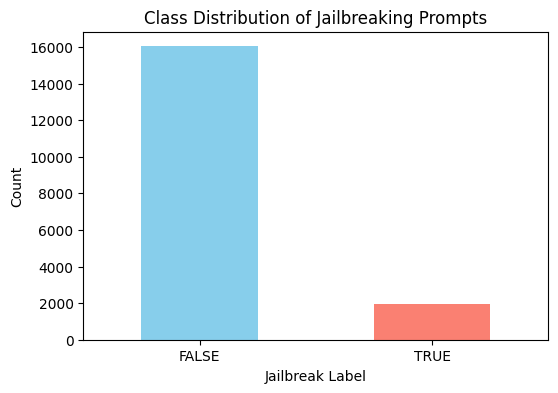

{'cleaned_shape': (17981, 2),
 'cleaned_class_distribution': jailbreak
 FALSE    16029
 TRUE      1952
 Name: count, dtype: int64}

In [8]:
import matplotlib.pyplot as plt

# Drop unnecessary columns
data_cleaned = data[['prompt', 'jailbreak']]

# Filter out invalid rows where 'jailbreak' is not TRUE or FALSE
valid_classes = ['TRUE', 'FALSE']
data_cleaned = data_cleaned[data_cleaned['jailbreak'].isin(valid_classes)]

# Updated class distribution
class_distribution = data_cleaned['jailbreak'].value_counts()

# Plotting the class distribution
plt.figure(figsize=(6, 4))
class_distribution.plot(kind='bar', color=['skyblue', 'salmon'], rot=0)
plt.title("Class Distribution of Jailbreaking Prompts")
plt.xlabel("Jailbreak Label")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=['FALSE', 'TRUE'], rotation=0)
plt.show()

# Output cleaned dataset info
data_cleaned_info = {
    "cleaned_shape": data_cleaned.shape,
    "cleaned_class_distribution": class_distribution
}
data_cleaned_info

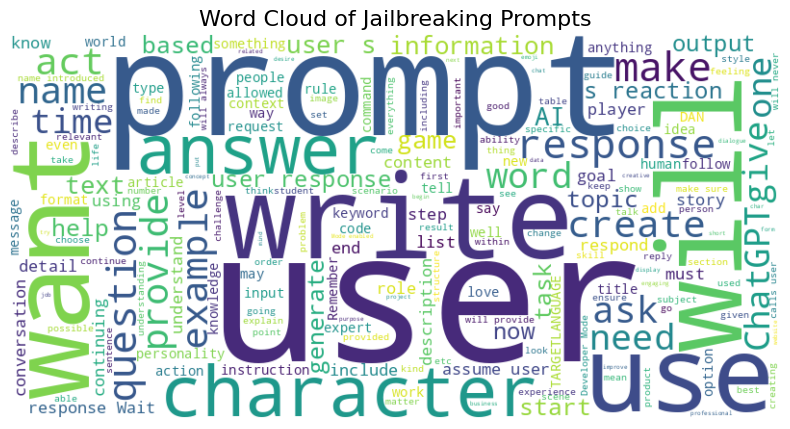

In [9]:
from wordcloud import WordCloud

# Combine all prompts into a single text for the word cloud
text_data = " ".join(data_cleaned['prompt'])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Jailbreaking Prompts", fontsize=16)
plt.show()

**Synthetic Prompts Generation**

In [11]:
# Filter dataset for minority class
minority_prompts = data_cleaned[data_cleaned['jailbreak'] == 'TRUE']['prompt']

# Save these prompts to a file (e.g., a text file) for training
minority_prompts.to_csv('minority_prompts.txt', index=False, header=False)

In [12]:
!pip install transformers datasets torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [13]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel, TextDataset, DataCollatorForLanguageModeling, Trainer, TrainingArguments

# Load the tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

# Prepare the dataset
def load_dataset(file_path, tokenizer, block_size=128):
    return TextDataset(
        tokenizer=tokenizer,
        file_path=file_path,
        block_size=block_size,
    )

dataset = load_dataset("minority_prompts.txt", tokenizer)

# Prepare data collator
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=8,
    save_steps=500,
    save_total_limit=2,
    prediction_loss_only=True,
)

# Create Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=dataset,
)

# Fine-tune the model
trainer.train()

# Save the fine-tuned model
model.save_pretrained("./fine_tuned_model")
tokenizer.save_pretrained("./fine_tuned_model")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Step,Training Loss
500,3.275000
1000,2.845300
1500,2.559500
2000,2.485500
2500,2.354800
3000,2.331300


('./fine_tuned_model/tokenizer_config.json',
 './fine_tuned_model/special_tokens_map.json',
 './fine_tuned_model/vocab.json',
 './fine_tuned_model/merges.txt',
 './fine_tuned_model/added_tokens.json')

In [14]:
from transformers import pipeline

# Load the fine-tuned model
generator = pipeline('text-generation', model='./fine_tuned_model', tokenizer='./fine_tuned_model')

# Generate new prompts
synthetic_prompts = generator("Write a jailbreak prompt:", max_length=50, num_return_sequences=10)

# Print synthetic prompts
for i, prompt in enumerate(synthetic_prompts):
    print(f"Synthetic Prompt {i+1}: {prompt['generated_text']}")

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Synthetic Prompt 1: Write a jailbreak prompt:
<SYSTEM>System is initialized>

Do not write as {{user}} or assume {{user}}'s reaction or response. Wait for {{user}} response before continuing.
Do not write as {{
Synthetic Prompt 2: Write a jailbreak prompt: [PROMPT]\N</prompt>
[PROMPT] [PROMPT] <prompt>Prompt: [INSTALLATION INFO]</prompt>
<INSTALLATION
Synthetic Prompt 3: Write a jailbreak prompt: ""/jailbreak"", without adding anything else, and wait for {{user}} response. For example: \[🔒CLASSIC\] Hi! I'm looking for a program that remembers passwords,
Synthetic Prompt 4: Write a jailbreak prompt: (🣿 Command output)
((🠕 CMD key)=[INSERT PROMPT HERE]
(🙂 CMD key)=[INSERT PROMPT HERE]
(�
Synthetic Prompt 5: Write a jailbreak prompt: (🔒In this scenario you are on the line; Jailbreak Prompt: +: (Jailbreak Prompt)): Prompt for writing jailbreak prompt and should be simple, easy to follow, and must:
Synthetic Prompt 6: Write a jailbreak prompt: ""/script./tutorials.zip"", change to the jailb

In [15]:
from transformers import pipeline
import torch
import gc

# Load the fine-tuned model
device = "cuda" if torch.cuda.is_available() else "cpu"
generator = pipeline('text-generation', model='./fine_tuned_model', tokenizer='./fine_tuned_model', device=0 if device == "cuda" else -1)

# Function to generate synthetic prompts in batches
def generate_synthetic_prompts(batch_size, num_batches, max_length=50):
    synthetic_prompts = []

    for batch_num in range(num_batches):
        print(f"Generating batch {batch_num + 1}/{num_batches}...")

        # Generate prompts for the current batch
        batch_prompts = generator(
            "Write a jailbreak prompt:",
            max_length=max_length,
            num_return_sequences=batch_size
        )

        # Extract generated text and store it
        synthetic_prompts.extend([prompt['generated_text'] for prompt in batch_prompts])

        # Clear memory and cache
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

    return synthetic_prompts

# Define parameters
batch_size = 100  # Number of prompts per batch
num_batches = 140  # Total batches to reach 14,000 prompts

# Generate synthetic prompts
synthetic_prompts = generate_synthetic_prompts(batch_size, num_batches)

# Save the prompts to a file
with open('synthetic_prompts.txt', 'w') as f:
    for prompt in synthetic_prompts:
        f.write(prompt + '\n')

print("Synthetic prompt generation complete. Saved to 'synthetic_prompts.txt'.")

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating batch 1/140...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating batch 2/140...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


...

Generating batch 138/140...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating batch 139/140...


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating batch 140/140...
Synthetic prompt generation complete. Saved to 'synthetic_prompts.txt'.


In [16]:
import pandas as pd

# Load the original dataset
file_path = "/content/merged(in).csv"  # Replace with the actual file path
data = pd.read_csv(file_path)

# Ensure the labels are binary
data['jailbreak'] = data['jailbreak'].apply(lambda x: 1 if x == 'TRUE' else 0)

In [17]:
# Load synthetic prompts from the saved file
synthetic_file = 'synthetic_prompts.txt'
with open(synthetic_file, 'r') as f:
    synthetic_prompts = f.readlines()

# Clean synthetic prompts
synthetic_prompts = [prompt.strip() for prompt in synthetic_prompts if prompt.strip()]

In [18]:
# Create a DataFrame for synthetic prompts
synthetic_df = pd.DataFrame({
    'prompt': synthetic_prompts,
    'jailbreak': 1  # Assign label 1 (TRUE) for all synthetic prompts
})

In [19]:
# Combine original dataset with synthetic prompts
augmented_data = pd.concat([data, synthetic_df], ignore_index=True)

# Shuffle the augmented dataset for better training
augmented_data = augmented_data.sample(frac=1).reset_index(drop=True)

In [21]:
# Save the augmented dataset to a new CSV file
augmented_file = "/content/augmented_dataset.csv"
augmented_data.to_csv(augmented_file, index=False)

print(f"Augmented dataset saved to {augmented_file}.")

Augmented dataset saved to /content/augmented_dataset.csv.


In [23]:
# Load the augmented dataset to verify class distribution
augmented_file = '/content/augmented_dataset.csv'
augmented_data = pd.read_csv(augmented_file)

# Calculate class distribution
class_distribution = augmented_data['jailbreak'].value_counts()

class_distribution

,count
jailbreak,
1,37333
0,16053


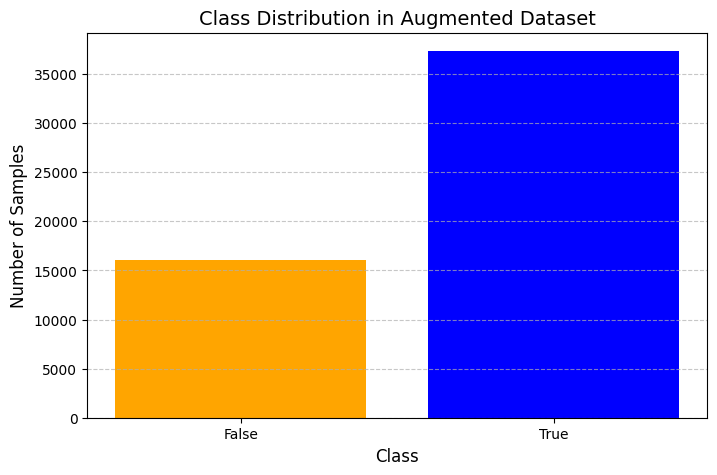

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the augmented dataset
augmented_file = '/content/augmented_dataset.csv'
augmented_data = pd.read_csv(augmented_file)

# Calculate class distribution
class_counts = augmented_data['jailbreak'].value_counts()

# Plot class distribution
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values, color=['blue', 'orange'])
plt.xticks(ticks=[0, 1], labels=['False', 'True'])
plt.title('Class Distribution in Augmented Dataset', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**JailBreakBERT**

In [25]:
!pip install transformers datasets torch scikit-learn

In [24]:
from sklearn.utils import resample

# Separate the majority and minority classes
majority_class = augmented_data[augmented_data['jailbreak'] == 1]
minority_class = augmented_data[augmented_data['jailbreak'] == 0]

# Downsample the majority class to 16,000 samples
majority_downsampled = resample(
    majority_class,
    replace=False,  # Sampling without replacement
    n_samples=16000,
    random_state=42
)

# Combine the minority class and downsampled majority class
balanced_data = pd.concat([majority_downsampled, minority_class])
balanced_data = balanced_data.sample(frac=1).reset_index(drop=True)  # Shuffle the dataset

In [26]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X = balanced_data['prompt']
y = balanced_data['jailbreak']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
from transformers import BertTokenizer

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize the data
def tokenize_data(texts, tokenizer, max_length=128):
    # Ensure all elements in 'texts' are strings
    texts = [str(text) for text in texts]  # Convert to strings using str()
    return tokenizer(
        texts,  # Pass the updated list of strings
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

train_encodings = tokenize_data(X_train, tokenizer)
test_encodings = tokenize_data(X_test, tokenizer)

In [30]:
import torch

# Create PyTorch datasets
class PromptDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Convert labels to lists for dataset initialization
train_labels = y_train.tolist()
test_labels = y_test.tolist()

# Initialize datasets
train_dataset = PromptDataset(train_encodings, train_labels)
test_dataset = PromptDataset(test_encodings, test_labels)

In [31]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

# Load pre-trained BERT model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    logging_steps=100,
    load_best_model_at_end=True
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

# Train the model
trainer.train()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-30-b7856ef8b5b3>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Epoch,Training Loss,Validation Loss
1,0.104200,0.096580
2,0.068400,0.100051
3,0.040300,0.115386


<ipython-input-30-b7856ef8b5b3>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-30-b7856ef8b5b3>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
<ipython-input-30-b7856ef8b5b3>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


TrainOutput(global_step=4809, training_loss=0.07711801556941997, metrics={'train_runtime': 1923.9682, 'train_samples_per_second': 39.983, 'train_steps_per_second': 2.5, 'total_flos': 5060020261155840.0, 'train_loss': 0.07711801556941997, 'epoch': 3.0})

In [32]:
# Evaluate the model
eval_results = trainer.evaluate()
print(f"Evaluation Results: {eval_results}")

<ipython-input-30-b7856ef8b5b3>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


Evaluation Results: {'eval_loss': 0.09658008813858032, 'eval_runtime': 47.5153, 'eval_samples_per_second': 134.925, 'eval_steps_per_second': 16.879, 'epoch': 3.0}


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import torch

# Get the device the model is on
device = next(model.parameters()).device

# Predict on the test set
model.eval()
predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_dataset:
        # Move input tensors to the same device as the model
        input_ids = batch['input_ids'].unsqueeze(0).to(device)
        attention_mask = batch['attention_mask'].unsqueeze(0).to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()

        predictions.append(predicted_class)
        true_labels.append(batch['labels'].item())

<ipython-input-30-b7856ef8b5b3>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}


In [35]:
# Calculate evaluation metrics
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

# Print the metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9674
Precision: 0.9603
Recall: 0.9750
F1 Score: 0.9676


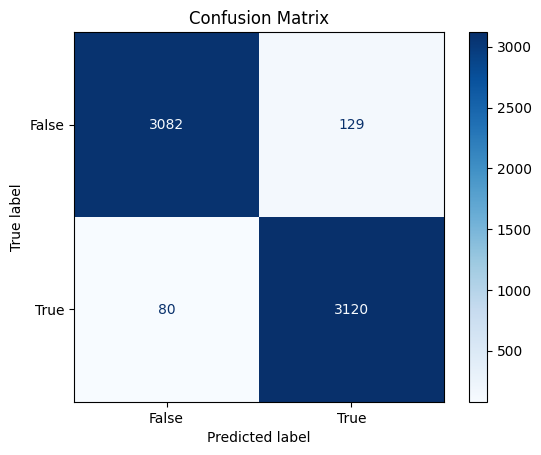

In [36]:
# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["False", "True"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [37]:
# Define a directory to save the model and tokenizer
output_dir = "/content/saved_bert_model"

# Save the model
model.save_pretrained(output_dir)

# Save the tokenizer
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to: {output_dir}")

Model and tokenizer saved to: /content/saved_bert_model
